In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import gaussian_kde
plt.style.use('ggplot')
#pd.set_option('max_columns', 200)

df = pd.read_csv('coaster_db.csv')

In [5]:
df = df[['coaster_name', #'Length', 'Speed', 
          'Location', 'Status', 
          'Opening date',#'Type', 
          'Manufacturer',
          #'Height restriction', 'Model', 'Height',
       #'Inversions', 'Lift/launch system', 'Cost', 'Trains', 'Park section',
       #'Duration', 'Capacity', 'G-force', 'Designer', 'Max vertical angle',
       #'Drop', 'Soft opening date', 'Fast Lane available', 'Replaced',
       #'Track layout', 'Fastrack available', 'Soft opening date.1',
       #'Closing date', 'Opened', 'Replaced by', 'Website',
       #'Flash Pass Available', 'Must transfer from wheelchair', 'Theme',
       #'Single rider line available', 'Restraint Style',
       #'Flash Pass available', 'Acceleration', 'Restraints', 'Name',
      'year_introduced',
      #'latitude', 'longitude', 
      'Type_Main',
       #'opening_date_clean', 'speed1', 'speed2', 'speed1_value', 'speed1_unit',
       'speed_mph',
        # 'height_value', 'height_unit', 
        'height_ft',
       #'Inversions_clean', 'Gforce_clean'
       ]].copy()

In [6]:
df = df.rename(columns={'coaster_name': 'Coaster Name'})

df = df.loc[df.duplicated(subset=['Coaster Name', 'Location', 'Opening date'])].reset_index(drop=True).copy()

df.shape

(97, 9)

<Axes: title={'center': 'Distribution of Coaster Speeds (MPH)'}, xlabel='Speed (MPH)', ylabel='Density'>

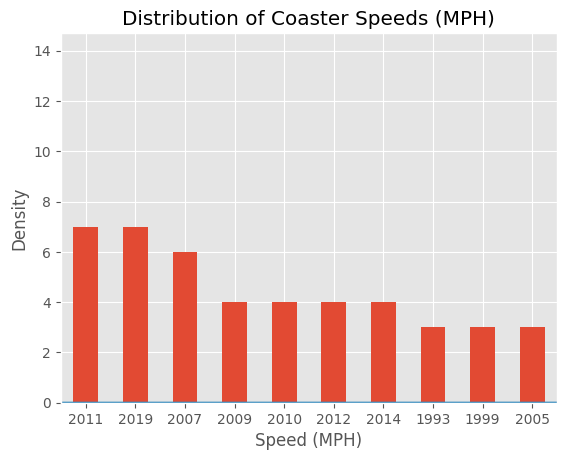

In [7]:
df['year_introduced'].value_counts()\
   .head(10)\
   .plot(kind='bar',
         title='Top 10 Years with the Most Coasters Introduced',
         xlabel='Year Introduced',
         ylabel='Number of Coasters Introduced')

df['speed_mph'].plot(kind='hist', \
                     bins=20,\
                    title='Distribution of Coaster Speeds (MPH)',\
                    xlabel='Speed (MPH)',\
                     ylabel='Frequency')

df['speed_mph'].plot(kind='kde', \
                     title='Distribution of Coaster Speeds (MPH)',\
                    xlabel='Speed (MPH)',\
                     ylabel='Frequency')

<Axes: >

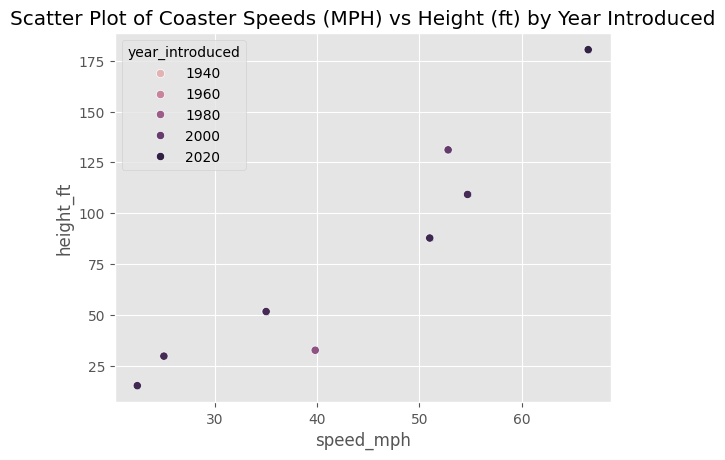

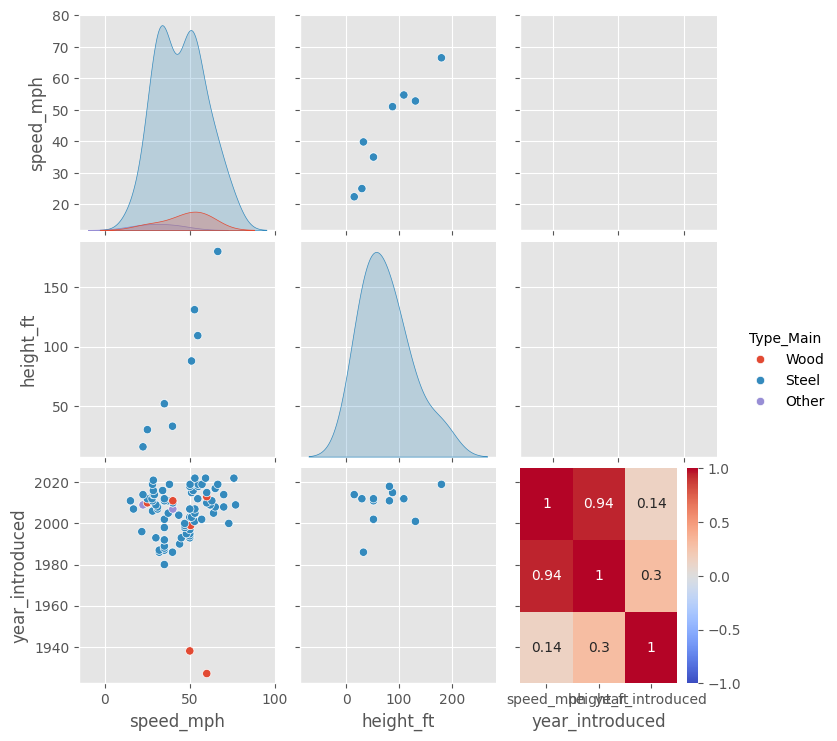

In [8]:
df.plot(kind='scatter', x='speed_mph', y='height_ft', \
        title='Scatter Plot of Coaster Speeds (MPH) vs Height (ft)')

ax = sns.scatterplot(data=df, x='speed_mph', y='height_ft' ,hue='year_introduced')
ax.set_title('Scatter Plot of Coaster Speeds (MPH) vs Height (ft) by Year Introduced')

sns.pairplot(df, vars=['speed_mph', 'height_ft', 'year_introduced'], hue='Type_Main')

bro = df[['speed_mph', 'height_ft', 'year_introduced']].dropna().corr()

sns.heatmap(bro, annot=True, cmap='coolwarm', vmin=-1, vmax=1)

Location
Thorpe Park                        16.8
Chessington World of Adventures    22.4
Magic Kingdom                      25.0
Thorpe Park Resort                 27.7
Idlewild and Soak Zone             30.0
Canada's Wonderland                39.8
Lightwater Valley                  40.0
Pleasurewood Hills                 50.0
Conneaut Lake Park                 50.0
Six Flags Over Georgia             50.0
Kentucky Kingdom                   52.0
Warner Bros. Movie World           54.7
Disney California Adventure        55.0
Walibi Holland                     57.2
Crystal Beach Park                 60.0
Mt. Olympus Water & Theme Park     60.0
Cedar Point                        60.0
Carowinds                          62.0
SeaWorld Orlando                   65.0
Nagashima Spa Land                 66.5
Busch Gardens Tampa Bay            76.0
Six Flags New England              77.0
Revere Beach                        NaN
Six Flags Great Adventure           NaN
Name: mean, dtype: float64


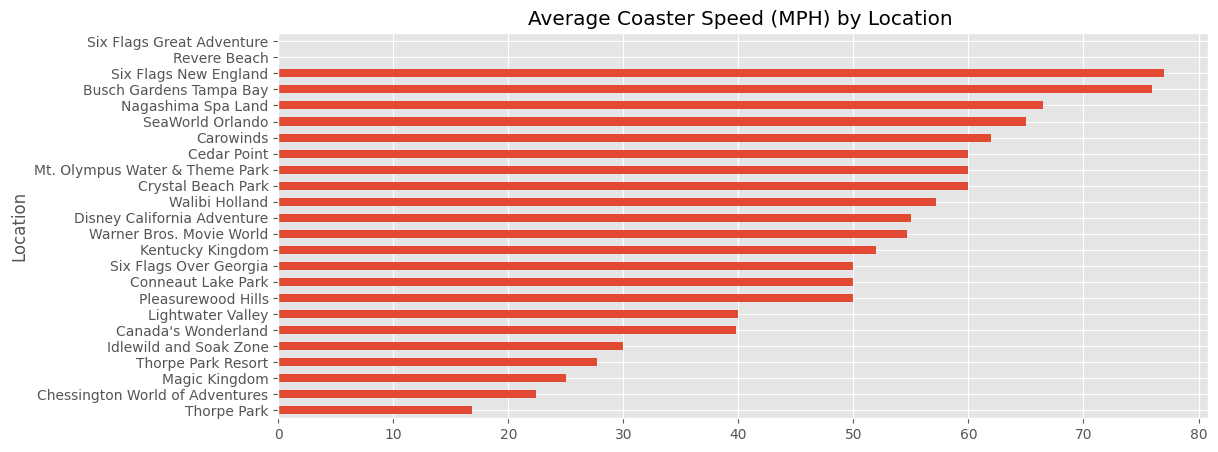

In [9]:
brox3 = (df.query('Location != "Other"')\
          .groupby('Location')['speed_mph']\
          .agg(['mean', 'count'])\
          .query('count >= 0')\
          .sort_values('mean')['mean'] 
)

print(brox3)

brox3.plot(kind='barh', figsize=(12, 5),title='Average Coaster Speed (MPH) by Location ')
 
plt.show()

In [10]:
print(df.shape)
print(df.head(20))
print(df.info())
print(df.describe())
print(df.head())
print(df.isna().sum())
print(df.duplicated())

(97, 9)
                            Coaster Name                Location     Status  \
0                  Crystal Beach Cyclone      Crystal Beach Park    Removed   
1                            Derby Racer            Revere Beach    Removed   
2            Blue Streak (Conneaut Lake)      Conneaut Lake Park     Closed   
3          Big Thunder Mountain Railroad                   Other        NaN   
4      Thunder Run (Canada's Wonderland)     Canada's Wonderland  Operating   
5                              La Vibora                   Other        NaN   
6          Big Thunder Mountain Railroad                   Other        NaN   
7                              La Vibora                   Other        NaN   
8   Flashback (Six Flags Magic Mountain)                   Other        NaN   
9                         Alpine Bobsled                   Other        NaN   
10    Ultra Twister (Nagashima Spa Land)      Nagashima Spa Land  Operating   
11             Ultra Twister (Six Flags)    

In [11]:
#Check for diplicates
print(df.loc[df.duplicated(subset=['Coaster Name'])])

                            Coaster Name          Location     Status  \
6          Big Thunder Mountain Railroad             Other        NaN   
7                              La Vibora             Other        NaN   
12         Big Thunder Mountain Railroad             Other        NaN   
13  Flashback (Six Flags Magic Mountain)             Other        NaN   
17                      Batman: The Ride             Other        NaN   
18                      Batman: The Ride             Other        NaN   
21                      Batman: The Ride             Other        NaN   
22                        Alpine Bobsled             Other        NaN   
24                      Batman: The Ride             Other        NaN   
25           Boomerang: Coast to Coaster             Other        NaN   
32                      Batman: The Ride             Other        NaN   
41                   Journey to Atlantis  SeaWorld Orlando  Operating   
43               American Dreier Looping           

In [12]:
print(df.columns)


Index(['Coaster Name', 'Location', 'Status', 'Opening date', 'Manufacturer',
       'year_introduced', 'Type_Main', 'speed_mph', 'height_ft'],
      dtype='str')


In [13]:
#Checking an example duplicate
print(df.query("`Coaster Name` == 'Crystal Beach Cyclone'"))

            Coaster Name            Location   Status Opening date  \
0  Crystal Beach Cyclone  Crystal Beach Park  Removed         1926   

         Manufacturer  year_introduced Type_Main  speed_mph  height_ft  
0  Traver Engineering             1927      Wood       60.0        NaN  


In [14]:
print(df['year_introduced'].value_counts())

year_introduced
2011    7
2019    7
2007    6
2009    4
2010    4
2012    4
2014    4
1993    3
1999    3
2005    3
2008    3
2015    3
2016    3
2018    3
2021    3
2022    3
1986    2
1987    2
1989    2
1992    2
1995    2
1998    2
2000    2
2002    2
2003    2
2004    2
2017    2
1927    1
1937    1
1938    1
1980    1
1988    1
1990    1
1994    1
1996    1
1997    1
2001    1
2006    1
2013    1
Name: count, dtype: int64
